The mouse kidney Slide-seq data: [gene expression data and BAM files](https://singlecell.broadinstitute.org/single_cell/study/SCP354/slide-seq-study).

The loom files of unspliced and spliced counts was processed from the BAM files by [Velocyto](https://github.com/velocyto-team/velocyto.py).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
data_path="../data/T3_Mouse_Kidney_Slideseq_Puck18052823/"
adata=sc.read_loom(data_path+"180528_23_kidney_MESWD.loom")
adata.obs.index = adata.obs.index.str.replace("180528_23_kidney_MESWD:", "", regex=False)
adata_raw=sc.read(data_path+"adata_anno.h5ad")
label_df=pd.read_csv(data_path+"adata_obs_anno.csv", index_col=0)
common_idx = adata.obs.index.intersection(adata_raw.obs.index)
label_df=label_df.loc[common_idx].copy()
adata_raw=adata_raw[common_idx].copy()
adata=adata[common_idx].copy()
adata.obs[['xcoord', 'ycoord', 'label']]=label_df.loc[label_df.index, ['xcoord', 'ycoord', 'annotation']]
adata.obs['label'] = adata.obs['label'].astype(str)
adata.obsm["spatial"] = adata.obs[['xcoord', 'ycoord']].to_numpy()

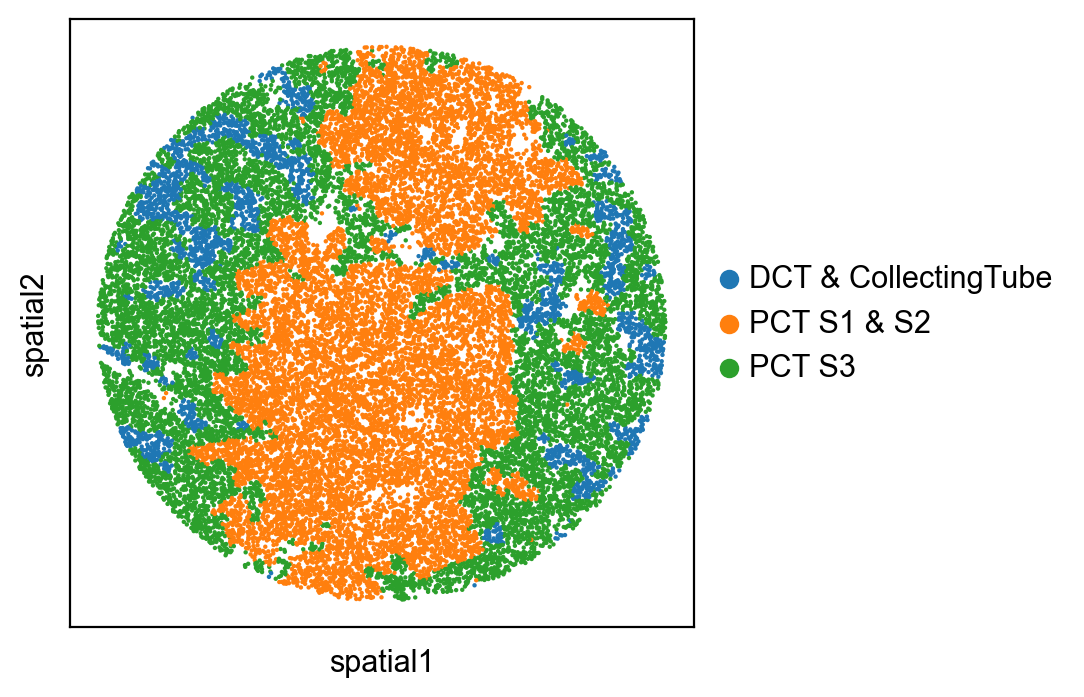

In [3]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(adata, basis="spatial", color="label", title="", s=10)

# Run model

In [4]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.07 0.87 0.05]


AnnData object with n_obs × n_vars = 22690 × 56305
    obs: 'xcoord', 'ycoord', 'label'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'label_colors'
    obsm: 'spatial'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [5]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 51331 genes that are detected 2 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:29) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [6]:
stv.Cal_Spatial_Net(adata, rad_cutoff=80)

------Calculating spatial graph...
The graph contains 575272 edges, 22690 cells.
25.3535 neighbors per cell on average.


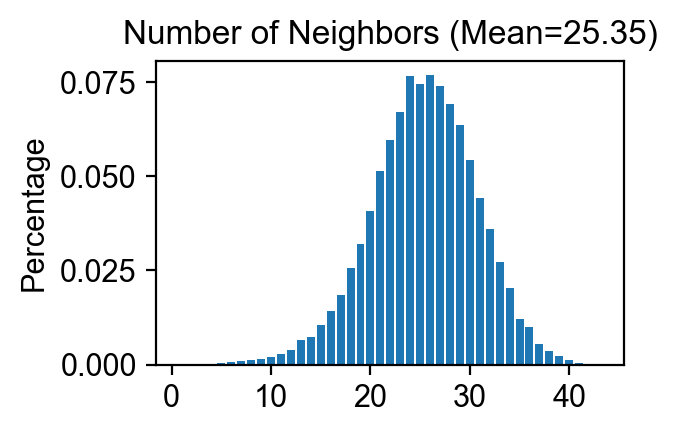

In [7]:
stv.Stats_Spatial_Net(adata)

In [8]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=1234, device = 'cuda:0')

Size of Input:  (22690, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:36<00:00, 10.38it/s]


In [9]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/22690 [00:00<?, ?cells/s]

    finished (0:01:05) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [10]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:05) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


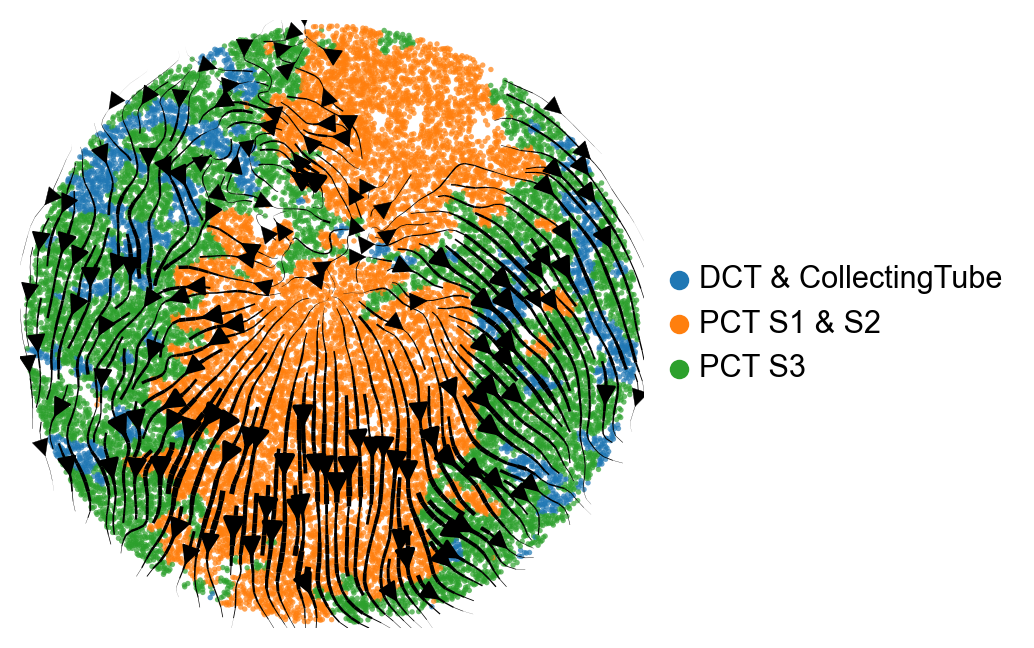

In [11]:
plt.rcParams["figure.figsize"] = (4, 4)
stv.velocity_embedding_stream(adata, basis='spatial', color="label", title="", legend_loc="right", alpha=0.7, size=15, 
                              linewidth=1.5, arrow_size=1.5)

In [12]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")

# Pseudotime

In [13]:
cx = (adata.obsm['spatial'][:, 0].max() + adata.obsm['spatial'][:, 0].min()) / 2
cy = (adata.obsm['spatial'][:, 1].max() + adata.obsm['spatial'][:, 1].min()) / 2
dtc = np.sqrt((adata.obsm['spatial'][:, 0] - cx)**2 + (adata.obsm['spatial'][:, 1] - cy)**2)
adata.obs['dtc'] = dtc
root_barcodes = adata.obs.nsmallest(10, 'dtc').index
adata.obs.loc[root_barcodes, 'root'] = True
stv.latent_time(adata, vkey='velocity', root_key='root')

computing latent time using root as prior
    finished (0:00:06) --> added 
    'latent_time', shared time (adata.obs)


(129.01305755395694, 5402.125791366903, 385.6247029938223, 5648.385910026925)

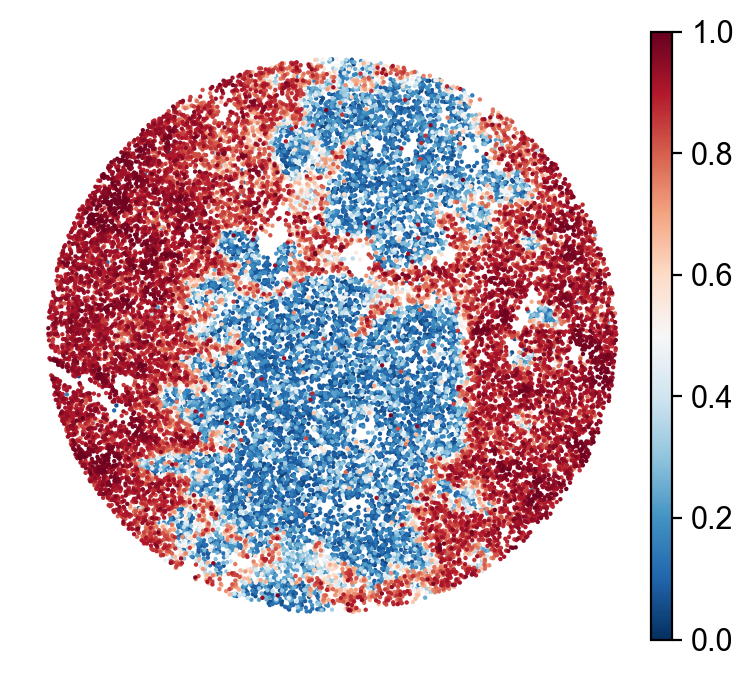

In [14]:
plt.rcParams["figure.figsize"] = (4.4, 4)
sc.pl.embedding(adata, basis="spatial", color="velocity_pseudotime", title="", s=10, show=False)
plt.axis('off')